In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("train.csv")

df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [2]:
print("Пропуски до обработки:")
print(df.isnull().sum())

Пропуски до обработки:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


In [3]:
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']
for col in cat_cols:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)

print("Пропуски после обработки:", df.isnull().sum().sum())

Пропуски после обработки: 399


In [4]:
scaler = MinMaxScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])

df[num_cols].describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,0.364434,0.015356,0.015042,0.007218,0.013593,0.012359
std,0.181537,0.046103,0.053527,0.025456,0.050230,0.046995
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.253165,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.341772,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.468354,0.002862,0.002046,0.000936,0.002365,0.001657
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df = pd.get_dummies(df, columns=['HomePlanet', 'Destination'], drop_first=True)

bool_features = ['CryoSleep', 'VIP', 'Transported']
for col in bool_features:
    if col in df.columns:
        df[col] = df[col].astype(int)

df.drop(['PassengerId', 'Cabin', 'Name'], axis=1, inplace=True, errors='ignore')

print("Готовый датасет:")
df.head()

Готовый датасет:


,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Europa,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e
0,0,0.493671,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,True,False,False,True
1,0,0.303797,0,0.007608,0.000302,0.001064,0.024500,0.001823,1,False,False,False,True
2,0,0.734177,1,0.003001,0.119948,0.000000,0.299670,0.002030,0,True,False,False,True
3,0,0.417722,0,0.000000,0.043035,0.015793,0.148563,0.007997,0,True,False,False,True
4,0,0.202532,0,0.021149,0.002348,0.006428,0.025214,0.000083,1,False,False,False,True


In [6]:
from sklearn.model_selection import train_test_split

X = df.drop(['Transported'], axis=1)
y = df['Transported']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)

X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Обучающая выборка: {X_train.shape[0]} строк")
print(f"Тестовая выборка: {X_test.shape[0]} строк")

Обучающая выборка: 5215 строк
Тестовая выборка: 1739 строк


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

X_reg = df.drop(['Spa'], axis=1)
y_reg = df['Spa']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lin_model = LinearRegression()
lin_model.fit(X_train_r, y_train_r)

y_pred_r = lin_model.predict(X_test_r)

print("MSE:", mean_squared_error(y_test_r, y_pred_r))
print("MAE:", mean_absolute_error(y_test_r, y_pred_r))

MSE: 0.0024095758416005247
MAE: 0.02228118778292507


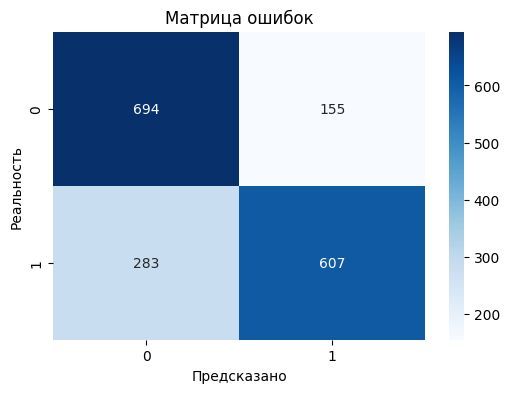

              precision    recall  f1-score   support

           0       0.71      0.82      0.76       849
           1       0.80      0.68      0.73       890

    accuracy                           0.75      1739
   macro avg       0.75      0.75      0.75      1739
weighted avg       0.75      0.75      0.75      1739



In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.title('Матрица ошибок')
plt.show()

print(classification_report(y_test, y_pred))